# Raster Data processing for Kitui Road water Harvesting project.
This notebook focuses on preparing raster data  for the Kitui road water harvesting suitability analysis.The raster processing workflow includes
loading raster layers,checking their coordinates reference systems,clipping them to Kitui county boundary,reprojecting them to EPSG:32737.
The raster datasets include the Digital elevation model (DEM),rainfall,landuselandcover(LULC) soil depth and other raster based criteria used in the road water harveting model.

## Purpose for Raster processing 
Raster processing is important because most suitability criteria are represented as grid based data.
In this project,raster processing prepares the data for deriving slope,reclassifying suitability classes and combining criteria using the AHP-
based weighted overlay meathod.

In [5]:
# import libraries
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
print('Done')


Done


In [6]:
# define paths
raw = Path('../data/raw')
processed =Path('../data/processed')

dem_path = raw / 'Kenya_SRTM30meters.tif'
kitui_boundary = processed / 'kitui_boundary.shp'
dem_path

WindowsPath('../data/raw/Kenya_SRTM30meters.tif')

In [84]:
# Open Kitui County boundary
kitui = gpd.read_file(kitui_boundary)

# check the crs of the DEM
with rasterio.open(dem_path) as dem:
    print(dem.crs)
# Reproject Kitui boundary  to match the DEM CRS
kitui_4326 = kitui.to_crs('EPSG:4326')

# convert Kitui county geometry to GeoJson format
geometry = kitui_4326.geometry.values

# Open DEM and clip DEM raster
with rasterio.open(dem_path) as src:
    clipped_dem, clipped_transform = mask(
        src,
        geometry,
        crop=True
    )
# Copy metadata
    clipped_meta = src.meta.copy()

# Update metadata
    clipped_meta.update({
    'driver': 'GTiff',
    'height': clipped_dem.shape[1],
    'width' : clipped_dem.shape[2],
    'transform':clipped_transform
})
print('Done')

EPSG:4326
Done


In [8]:
# save the Kitui County DEM
clipped_dem_path = processed / 'kitui_dem.tiff'
with rasterio.open(clipped_dem_path, 'w', **clipped_meta) as dest:
    dest.write(clipped_dem)
print('Done')


Done


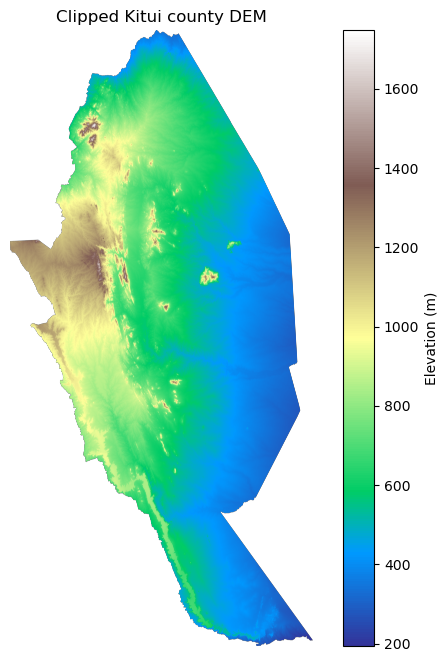

In [9]:
# Remove no data values from plotting
import numpy as np
with rasterio.open(clipped_dem_path) as src:
    dem_data = src.read(1)
    nodata = src.nodata
dem_clean = np.where(dem_data == nodata,np.nan,dem_data)

# Visualize the clipped dem
fig, ax = plt.subplots(figsize=(8,8))
dem_map = ax.imshow(dem_clean,cmap="terrain")
ax.set_title('Clipped Kitui county DEM')
ax.axis('off')
plt.colorbar(dem_map,ax=ax,label='Elevation (m)')

In [10]:
# Reproject clipped kitui county dem  back to EPSG:32737
from rasterio.warp import calculate_default_transform, reproject, Resampling

# define path
clipped_dem_path = processed / 'kitui_dem.tiff'
reprojected_dem_path = processed / 'kitui_dem_32737.tif'

with rasterio.open(clipped_dem_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs,
        'EPSG:32737',
        src.width,
        src.height,
        *src.bounds


    )

    kwargs = src.meta.copy()
    kwargs.update({
        'crs': "EPSG:32737",
        'transform': transform,
        'width': width,
        'height': height
    })


    with rasterio.open(reprojected_dem_path, 'w', **kwargs) as dst:
        band = 1
        
   
        reproject(
            source=rasterio.band(src,band),
            destination=rasterio.band(dst,band),
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:32737',
            resampling=Resampling.bilinear

        )
print('Done')

Done


In [11]:
with rasterio.open(reprojected_dem_path) as dem:
    print('CRS',dem.crs)

CRS EPSG:32737


## Slope deriviation from DEM
The reprojected DEM is used to derive slope for Kitui county.Slope is an important terrain factor in road RWH suitability analysis because
it influences run off speed,infiltration and the construction suitability of different water harvesting stractures.

In [12]:
with rasterio.open(reprojected_dem_path) as src:
    dem = src.read(1).astype("float32")
    dem_meta = src.meta.copy()
    nodata = src.nodata
    x_res, y_res = src.res

# Replace NoData with NaN
if nodata is not None:
    dem = np.where(dem == nodata, np.nan, dem)

# Also remove extreme negative values if they exist
dem = np.where(dem < -1000, np.nan, dem)

print("DEM min:", np.nanmin(dem))
print("DEM max:", np.nanmax(dem))
print("DEM mean:", np.nanmean(dem))

DEM min: 193.0
DEM max: 1747.0
DEM mean: 634.66846


In [13]:
dy, dx = np.gradient(dem, abs(y_res), abs(x_res))

slope = np.degrees(
    np.arctan(
        np.sqrt(dx**2 + dy**2)
    )
)

slope_output = np.where(np.isnan(slope), -9999, slope)

print("Slope min:", np.nanmin(slope))
print("Slope max:", np.nanmax(slope))
print("Slope mean:", np.nanmean(slope))

Slope min: 0.0
Slope max: 74.7934
Slope mean: 3.3447838


## Slope Reclassification

The slope raster contains continuous slope values in degrees. To use slope in suitability analysis, the raster is reclassified into suitability scores. Gentle slopes are generally more suitable for road water harvesting because they reduce erosion risk and support water retention, while very steep slopes are less suitable due to faster runoff and higher erosion potential.

In [14]:
slope_clean = np.where(slope_output == -9999, np.nan, slope_output)

slope_reclass = np.full(slope_clean.shape, -9999, dtype="float32")

slope_reclass[(slope_clean >= 0) & (slope_clean <= 5)] = 5
slope_reclass[(slope_clean > 5) & (slope_clean <= 10)] = 4
slope_reclass[(slope_clean > 10) & (slope_clean <= 20)] = 3
slope_reclass[(slope_clean > 20) & (slope_clean <= 30)] = 2
slope_reclass[(slope_clean > 30)] = 1

unique_scores, counts = np.unique(
    slope_reclass[slope_reclass != -9999],
    return_counts=True
)

print("Slope suitability scores:", unique_scores)
print("Pixel counts:", counts)

Slope suitability scores: [1. 2. 3. 4. 5.]
Pixel counts: [  138136   495733   951988  2993152 27594583]


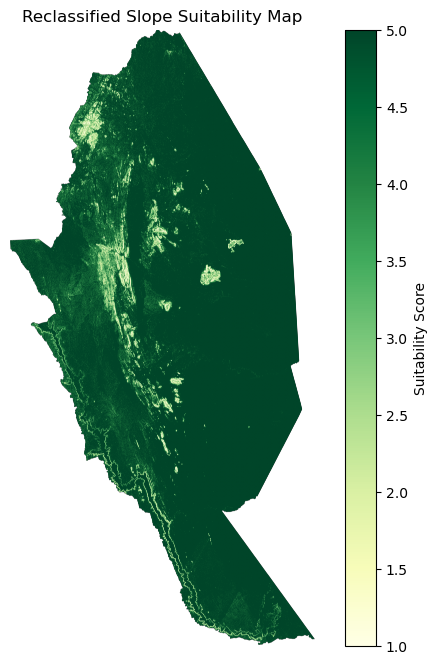

In [15]:
slope_reclass_display = np.where(
    slope_reclass == -9999,
    np.nan,
    slope_reclass
)

fig, ax = plt.subplots(figsize=(8, 8))

slope_reclass_map = ax.imshow(
    slope_reclass_display,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Reclassified Slope Suitability Map")
ax.axis("off")

plt.colorbar(
    slope_reclass_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

In [16]:
slope_reclass_path = processed / "kitui_slope_reclassified.tif"

with rasterio.open(slope_reclass_path) as src:
    slope_meta = src.meta.copy()

slope_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

with rasterio.open(slope_reclass_path, "w", **slope_meta) as dst:
    dst.write(slope_reclass.astype("float32"), 1)

print("Done")

Done


## Rainfall Raster Processing

Rainfall is one of the key criteria used in road water harvesting suitability analysis because areas receiving more rainfall have greater potential to generate runoff. In this project, rainfall data will be prepared by checking its CRS, clipping it to the Kitui County boundary, reprojecting it to EPSG:32737, and later reclassifying it into suitability scores.

The processed rainfall raster will be used together with slope, soil, land cover, soil depth, roads, streams, and agricultural proximity layers in the AHP-based weighted overlay analysis.

In [17]:
# Define rainfall input path
rainfall_path = raw / 'Precipitation (1).tif'

# Check rainfall raster information
with rasterio.open(rainfall_path) as src:
    print("Rainfall CRS:", src.crs)
    print("Rainfall resolution:", src.res)
    print("Rainfall shape:", src.shape)
    print("Rainfall bounds:", src.bounds)
    print("Rainfall NoData:", src.nodata)

Rainfall CRS: EPSG:4326
Rainfall resolution: (0.00026949458523585647, 0.00026949458523585647)
Rainfall shape: (11189, 5493)
Rainfall bounds: BoundingBox(left=37.59557261874292, bottom=-3.068465347495462, right=39.07590637544348, top=-0.05309043329146373)
Rainfall NoData: None


## Rainfall Raster Reprojection

The rainfall raster is already clipped to Kitui County, but it is in EPSG:4326. It is reprojected to EPSG:32737 so that it matches the other processed spatial datasets and can be used together with slope, soil, roads, and other criteria in the suitability analysis.

In [18]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Define input and output paths
rainfall_path = raw / 'Precipitation (1).tif'
rainfall_32737_path = processed / "kitui_rainfall_32737.tif"

target_crs = "EPSG:32737"

# Reproject rainfall raster to EPSG:32737
with rasterio.open(rainfall_path) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        target_crs,
        src.width,
        src.height,
        *src.bounds
    )

    rainfall_meta = src.meta.copy()

    rainfall_meta.update({
        "crs": target_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(rainfall_32737_path, "w", **rainfall_meta) as dst:
        for band in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, band),
                destination=rasterio.band(dst, band),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear
            )

print("Done")

Done


## Visualizing Rainfall Raster

The reprojected rainfall raster is inspected and visualized to confirm that the raster values are valid before reclassification. Minimum, maximum, and mean rainfall values are checked to understand the rainfall distribution across Kitui County.

In [19]:
# Open the reprojected rainfall raster
with rasterio.open(rainfall_32737_path) as src:
    rainfall_data = src.read(1)
    rainfall_nodata = src.nodata

    print("Rainfall CRS:", src.crs)
    print("Rainfall resolution:", src.res)
    print("Rainfall shape:", src.shape)
    print("Rainfall NoData:", rainfall_nodata)

# Replace NoData values with NaN for analysis and visualization
rainfall_clean = np.where(rainfall_data == rainfall_nodata, np.nan, rainfall_data)

print("Minimum rainfall:", np.nanmin(rainfall_clean))
print("Maximum rainfall:", np.nanmax(rainfall_clean))
print("Mean rainfall:", np.nanmean(rainfall_clean))

Rainfall CRS: EPSG:32737
Rainfall resolution: (29.826599702229515, 29.826599702229515)
Rainfall shape: (11178, 5523)
Rainfall NoData: None
Minimum rainfall: 0.0
Maximum rainfall: 1650.3752889633183
Mean rainfall: 974.4965945556595


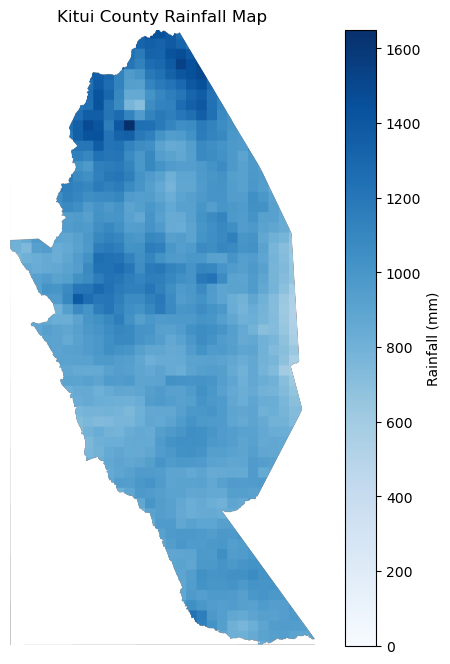

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

rainfall_map = ax.imshow(rainfall_clean, cmap="Blues")
ax.set_title("Kitui County Rainfall Map")
ax.axis("off")

plt.colorbar(rainfall_map, ax=ax, label="Rainfall (mm)")
plt.show()

In [21]:
print("Minimum rainfall:", np.nanmin(rainfall_clean))
print("Maximum rainfall:", np.nanmax(rainfall_clean))
print("Mean rainfall:", np.nanmean(rainfall_clean))

Minimum rainfall: 0.0
Maximum rainfall: 1650.3752889633183
Mean rainfall: 974.4965945556595


## Rainfall Reclassification

The rainfall raster contains continuous rainfall values. To use rainfall in the suitability analysis, the raster is reclassified into suitability scores. Areas with higher rainfall are assigned higher suitability scores because they have greater potential to generate runoff for road water harvesting.

In [22]:
zero_count = np.sum(rainfall_clean == 0)
total_valid_pixels = np.sum(~np.isnan(rainfall_clean))

print("Zero rainfall pixels:", zero_count)
print("Total valid pixels:", total_valid_pixels)
print("Percentage zero pixels:", (zero_count / total_valid_pixels) * 100)

Zero rainfall pixels: 42272
Total valid pixels: 34253392
Percentage zero pixels: 0.12340967574831713


### Cleaning Rainfall NoData Values

Some rainfall pixels have a value of 0 mm. Since these represent a very small proportion of the raster and may correspond to background or invalid pixels, they are treated as NoData and excluded from rainfall reclassification.

In [23]:
rainfall_clean = np.where(rainfall_clean == 0, np.nan, rainfall_clean)

print("Minimum rainfall after removing zero:", np.nanmin(rainfall_clean))
print("Maximum rainfall after removing zero:", np.nanmax(rainfall_clean))
print("Mean rainfall after removing zero:", np.nanmean(rainfall_clean))

Minimum rainfall after removing zero: 523.7970190048217
Maximum rainfall after removing zero: 1650.3752889633183
Mean rainfall after removing zero: 975.7007036302837


In [24]:
# Create an empty raster for rainfall suitability
rainfall_reclass = np.full(rainfall_clean.shape, -9999, dtype="float32")

# Reclassify rainfall into 5 suitability classes
rainfall_reclass[(rainfall_clean > 0) & (rainfall_clean <= 330)] = 1
rainfall_reclass[(rainfall_clean > 330) & (rainfall_clean <= 660)] = 2
rainfall_reclass[(rainfall_clean > 660) & (rainfall_clean <= 990)] = 3
rainfall_reclass[(rainfall_clean > 990) & (rainfall_clean <= 1320)] = 4
rainfall_reclass[(rainfall_clean > 1320) & (rainfall_clean <= 1650)] = 5

print("Done")

Done


## Visualizing Reclassified Rainfall

The reclassified rainfall raster is visualized to check the spatial distribution of rainfall suitability scores across Kitui County. Higher scores represent areas with higher rainfall and greater runoff generation potential.

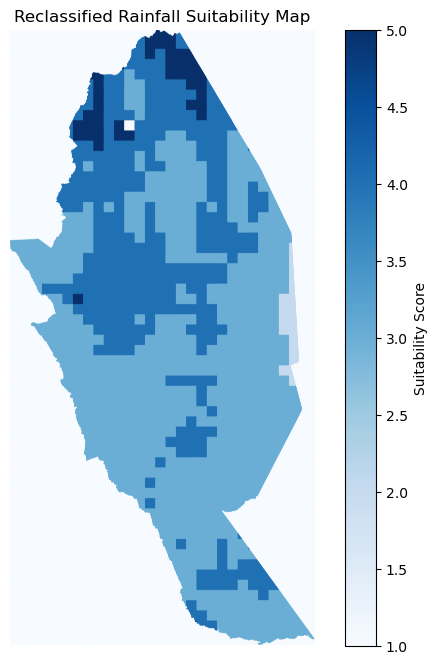

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

rainfall_reclass_map = ax.imshow(
    rainfall_reclass,
    cmap="Blues",
    vmin=1,
    vmax=5
)

ax.set_title("Reclassified Rainfall Suitability Map")
ax.axis("off")

plt.colorbar(
    rainfall_reclass_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

## Saving Reclassified Rainfall Raster

The reclassified rainfall raster is saved as a GeoTIFF file in the processed data folder. This output will be used later as one of the standardized input layers in the AHP-based weighted overlay suitability analysis.

In [26]:
# Define output path for reclassified rainfall
rainfall_reclass_path = processed / "kitui_rainfall_reclassified.tif"

# Copy metadata from the reprojected rainfall raster
with rasterio.open(rainfall_32737_path) as src:
    rainfall_meta = src.meta.copy()

# Update metadata for the reclassified raster
rainfall_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

# Save the reclassified rainfall raster
with rasterio.open(rainfall_reclass_path, "w", **rainfall_meta) as dst:
    dst.write(rainfall_reclass.astype("float32"), 1)

print("Done")

Done


In [27]:
with rasterio.open(rainfall_reclass_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("NoData:", src.nodata)

CRS: EPSG:32737
Resolution: (29.826599702229515, 29.826599702229515)
Shape: (11178, 5523)
NoData: -9999.0


## Land Cover Raster Processing

Land use and land cover is processed as one of the criteria for road water harvesting suitability analysis. Land cover influences runoff generation because different surfaces produce different amounts of runoff. Built-up areas and bare land generally produce more runoff, while vegetation-covered areas increase infiltration.

In this project, the land cover raster is prepared by checking its CRS, reprojecting it to EPSG:32737  and later reclassifying land cover classes into suitability scores

In [28]:
# Define land cover input and output paths
landcover_path = raw / 'kitui LULC.tif'
landcover_32737_path = processed / "kitui_landcover_32737.tif"

In [29]:
with rasterio.open(landcover_path) as src:
    print("Land cover CRS:", src.crs)
    print("Land cover resolution:", src.res)
    print("Land cover shape:", src.shape)
    print("Land cover bounds:", src.bounds)
    print("Land cover NoData:", src.nodata)
    print("Number of bands:", src.count)
    

Land cover CRS: EPSG:4326
Land cover resolution: (0.00026949458523585647, 0.00026949458523585647)
Land cover shape: (11189, 5492)
Land cover bounds: BoundingBox(left=37.59558750572046, bottom=-3.0685800925857434, right=39.07565176783578, top=-0.0532051783817451)
Land cover NoData: None
Number of bands: 1


In [30]:
target_crs = "EPSG:32737"

with rasterio.open(landcover_path) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        target_crs,
        src.width,
        src.height,
        *src.bounds
    )

    landcover_meta = src.meta.copy()

    landcover_meta.update({
        "crs": target_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(landcover_32737_path, "w", **landcover_meta) as dst:
        for band in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, band),
                destination=rasterio.band(dst, band),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )

print("Done")


Done


In [31]:
with rasterio.open(landcover_32737_path) as src:
    landcover_data = src.read(1)
    landcover_nodata = src.nodata

    print("Reprojected CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("NoData:", landcover_nodata)

Reprojected CRS: EPSG:32737
Resolution: (29.826589218266253, 29.826589218266253)
Shape: (11178, 5522)
NoData: None


In [32]:
unique_classes = np.unique(landcover_data)

print("Unique land cover classes:")
print(unique_classes)

Unique land cover classes:
[ 0 10 20 30 40 50 60 80 90]


### Cleaning Land Cover Background Values

The land cover raster contains a value of 0, which represents background or NoData pixels outside the valid land cover classes. This value is removed from visualization and excluded from reclassification.

In [33]:
# Remove background value 0 for display and analysis
landcover_clean = np.where(landcover_data == 0, np.nan, landcover_data)

# Check unique valid land cover classes
valid_landcover_classes = np.unique(landcover_clean[~np.isnan(landcover_clean)])

print("Valid land cover classes:")
print(valid_landcover_classes)

Valid land cover classes:
[10. 20. 30. 40. 50. 60. 80. 90.]


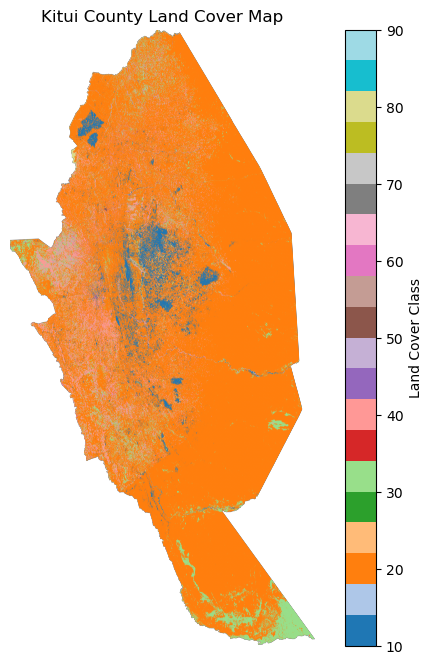

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

landcover_map = ax.imshow(landcover_clean, cmap="tab20")
ax.set_title("Kitui County Land Cover Map")
ax.axis("off")

plt.colorbar(landcover_map, ax=ax, label="Land Cover Class")
plt.show()

## Land Cover Reclassification

The land cover raster is reclassified into suitability scores based on how each land cover class influences runoff generation and road water harvesting suitability. Cropland, grassland, shrubland, and bare areas are considered more relevant for road water harvesting, while water bodies and wetlands are treated as unsuitable or restricted areas.

In [35]:
# Create an empty raster for land cover suitability
landcover_reclass = np.full(landcover_clean.shape, -9999, dtype="float32")

# Reclassify ESA WorldCover classes into suitability scores
landcover_reclass[landcover_clean == 10] = 2  # Tree cover
landcover_reclass[landcover_clean == 20] = 4  # Shrubland
landcover_reclass[landcover_clean == 30] = 4  # Grassland
landcover_reclass[landcover_clean == 40] = 5  # Cropland
landcover_reclass[landcover_clean == 50] = 3  # Built-up
landcover_reclass[landcover_clean == 60] = 4  # Bare / sparse vegetation
landcover_reclass[landcover_clean == 80] = 1  # Water bodies
landcover_reclass[landcover_clean == 90] = 1  # Wetland

print("Done")

Done


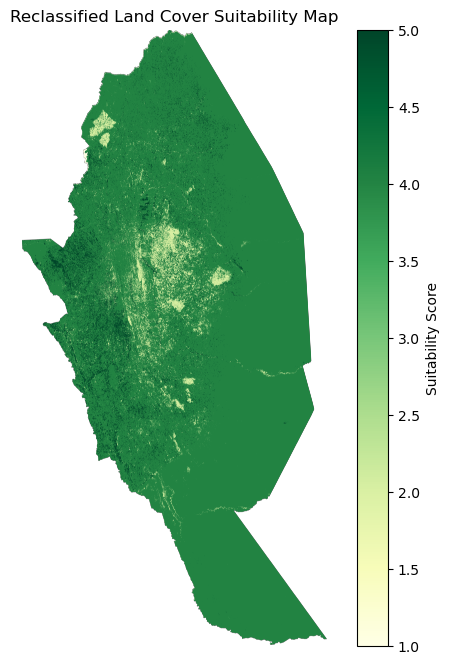

In [36]:
# Replace NoData with NaN for display
landcover_reclass_display = np.where(
    landcover_reclass == -9999,
    np.nan,
    landcover_reclass
)

fig, ax = plt.subplots(figsize=(8, 8))

landcover_reclass_map = ax.imshow(
    landcover_reclass_display,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Reclassified Land Cover Suitability Map")
ax.axis("off")

plt.colorbar(
    landcover_reclass_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

In [37]:
landcover_reclass_path = processed / "kitui_landcover_reclassified.tif"

with rasterio.open(landcover_32737_path) as src:
    landcover_meta = src.meta.copy()

landcover_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

with rasterio.open(landcover_reclass_path, "w", **landcover_meta) as dst:
    dst.write(landcover_reclass.astype("float32"), 1)

print("Done")

Done


## Soil Depth Raster Processing

Soil depth is processed as one of the raster criteria for road water harvesting suitability analysis. Soil depth influences water storage capacity, infiltration, and the feasibility of constructing structures such as farm ponds, mitre drains, and sand dams.

The soil depth raster is checked, cleaned, reprojected to EPSG:32737 if necessary, visualized, and later reclassified into suitability scores.

In [38]:
# Define soil depth input and output paths
soil_depth_path = raw / 'Kitui_SoilDepth_0_5cm.tif'
soil_depth_32737_path = processed / "kitui_soil_depth_32737.tif"

In [39]:
with rasterio.open(soil_depth_path) as src:
    print("Soil depth CRS:", src.crs)
    print("Soil depth resolution:", src.res)
    print("Soil depth shape:", src.shape)
    print("Soil depth bounds:", src.bounds)
    print("Soil depth NoData:", src.nodata)
    print("Number of bands:", src.count)

Soil depth CRS: ESRI:54009
Soil depth resolution: (250.0, 250.0)
Soil depth shape: (1492, 582)
Soil depth bounds: BoundingBox(left=3767410.554489456, bottom=-379461.8683610186, right=3912910.554489456, top=-6461.868361018598)
Soil depth NoData: None
Number of bands: 1


## Soil Depth Reprojection

The soil depth raster is provided in ESRI:54009, while the other project datasets are processed in EPSG:32737. The soil depth raster is therefore reprojected to EPSG:32737 so that it aligns with the DEM, slope, rainfall, land cover, roads, soil, and Kitui County boundary layers.

Bilinear resampling is used because soil depth is continuous raster data.

In [40]:
soil_depth_32737_path = processed / "kitui_soil_depth_32737.tif"

target_crs = "EPSG:32737"

with rasterio.open(soil_depth_path) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        target_crs,
        src.width,
        src.height,
        *src.bounds
    )

    soil_depth_meta = src.meta.copy()

    soil_depth_meta.update({
        "crs": target_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(soil_depth_32737_path, "w", **soil_depth_meta) as dst:
        for band in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, band),
                destination=rasterio.band(dst, band),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear
            )

print("Done")

Done


In [41]:
with rasterio.open(soil_depth_32737_path) as src:
    print("Soil depth CRS:", src.crs)
    print("Soil depth resolution:", src.res)
    print("Soil depth shape:", src.shape)
    print("Soil depth bounds:", src.bounds)
    print("Soil depth NoData:", src.nodata)

Soil depth CRS: EPSG:32737
Soil depth resolution: (232.44632510532543, 232.44632510532543)
Soil depth shape: (1435, 712)
Soil depth bounds: BoundingBox(left=343128.85059744905, bottom=9660663.054388914, right=508630.6340724408, top=9994223.530915055)
Soil depth NoData: None


## Visualizing Soil Depth Raster

The reprojected soil depth raster is inspected and visualized to understand the spatial distribution of soil depth across Kitui County. Minimum, maximum, and mean soil depth values are checked before reclassification into suitability scores.

In [42]:
# Open the reprojected soil depth raster
with rasterio.open(soil_depth_32737_path) as src:
    soil_depth_data = src.read(1)
    soil_depth_nodata = src.nodata

    print("Soil depth CRS:", src.crs)
    print("Soil depth resolution:", src.res)
    print("Soil depth shape:", src.shape)
    print("Soil depth NoData:", soil_depth_nodata)

# Clean soil depth raster for analysis and visualization
if soil_depth_nodata is not None:
    soil_depth_clean = np.where(
        soil_depth_data == soil_depth_nodata,
        np.nan,
        soil_depth_data
    )
else:
    soil_depth_clean = soil_depth_data.astype("float32")

print("Minimum soil depth:", np.nanmin(soil_depth_clean))
print("Maximum soil depth:", np.nanmax(soil_depth_clean))
print("Mean soil depth:", np.nanmean(soil_depth_clean))

Soil depth CRS: EPSG:32737
Soil depth resolution: (232.44632510532543, 232.44632510532543)
Soil depth shape: (1435, 712)
Soil depth NoData: None
Minimum soil depth: 0.0
Maximum soil depth: 681.0
Mean soil depth: 76.273026


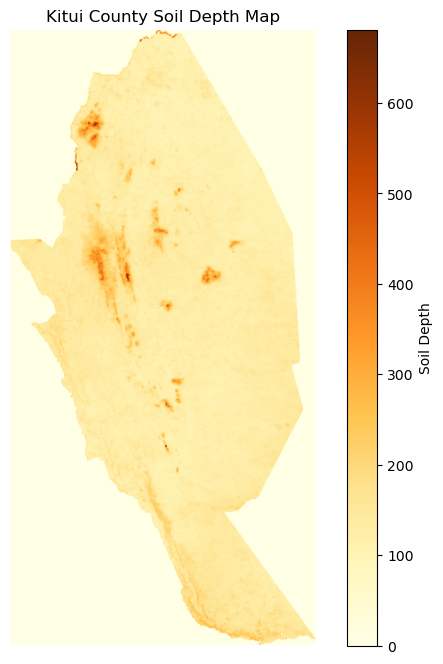

In [43]:
fig, ax = plt.subplots(figsize=(8, 8))

soil_depth_map = ax.imshow(
    soil_depth_clean,
    cmap="YlOrBr"
)

ax.set_title("Kitui County Soil Depth Map")
ax.axis("off")

plt.colorbar(
    soil_depth_map,
    ax=ax,
    label="Soil Depth"
)

plt.show()

## Soil Depth Reclassification

The soil depth raster is reclassified into suitability scores. Deeper soils are generally more suitable for water storage and infiltration, while very shallow soils are less suitable because they may limit excavation and reduce water holding capacity.

The reclassified soil depth layer will be used as one of the standardized criteria in the AHP-based weighted overlay suitability analysis.

In [44]:
soil_depth_clean = np.where(
    soil_depth_data <= 0,
    np.nan,
    soil_depth_data
)

print("Minimum soil depth:", np.nanmin(soil_depth_clean))
print("Maximum soil depth:", np.nanmax(soil_depth_clean))
print("Mean soil depth:", np.nanmean(soil_depth_clean))

Minimum soil depth: 1.0
Maximum soil depth: 681.0
Mean soil depth: 137.01919472527473


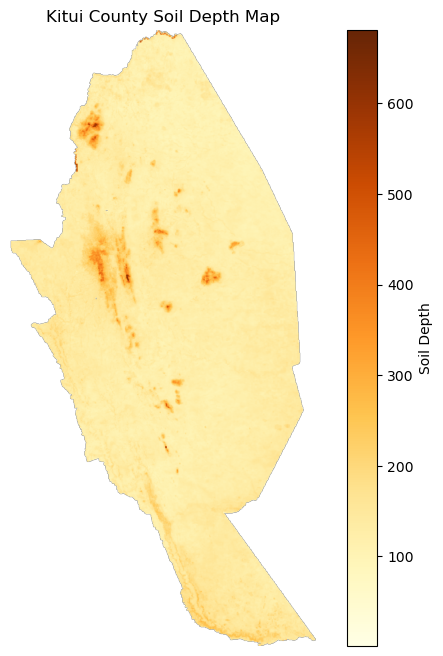

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

soil_depth_map = ax.imshow(
    soil_depth_clean,
    cmap="YlOrBr"
)

ax.set_title("Kitui County Soil Depth Map")
ax.axis("off")

plt.colorbar(
    soil_depth_map,
    ax=ax,
    label="Soil Depth"
)

plt.show()

In [46]:
soil_depth_clean = np.where(
    soil_depth_data <= 0,
    np.nan,
    soil_depth_data
)

print("Minimum soil depth after cleaning:", np.nanmin(soil_depth_clean))
print("Maximum soil depth after cleaning:", np.nanmax(soil_depth_clean))
print("Mean soil depth after cleaning:", np.nanmean(soil_depth_clean))

Minimum soil depth after cleaning: 1.0
Maximum soil depth after cleaning: 681.0
Mean soil depth after cleaning: 137.01919472527473


In [47]:
# Create an empty raster for soil depth suitability
soil_depth_reclass = np.full(soil_depth_clean.shape, -9999, dtype="float32")

# Reclassify soil depth into suitability scores
soil_depth_reclass[(soil_depth_clean > 0) & (soil_depth_clean <= 50)] = 1
soil_depth_reclass[(soil_depth_clean > 50) & (soil_depth_clean <= 100)] = 2
soil_depth_reclass[(soil_depth_clean > 100) & (soil_depth_clean <= 200)] = 3
soil_depth_reclass[(soil_depth_clean > 200) & (soil_depth_clean <= 400)] = 4
soil_depth_reclass[(soil_depth_clean > 400)] = 5

print("Done")

Done


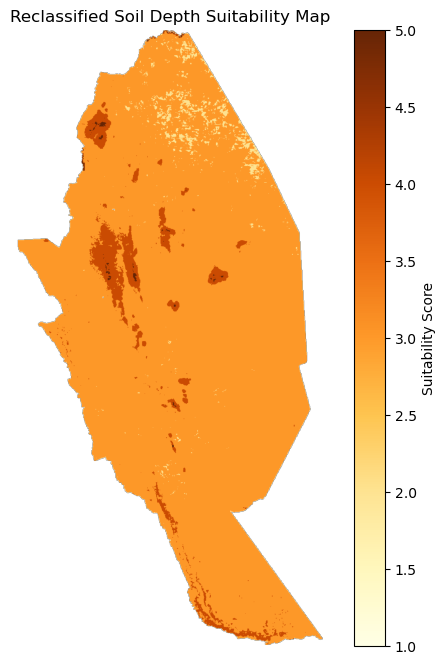

In [48]:
soil_depth_reclass_display = np.where(
    soil_depth_reclass == -9999,
    np.nan,
    soil_depth_reclass
)

fig, ax = plt.subplots(figsize=(8, 8))

soil_depth_reclass_map = ax.imshow(
    soil_depth_reclass_display,
    cmap="YlOrBr",
    vmin=1,
    vmax=5
)

ax.set_title("Reclassified Soil Depth Suitability Map")
ax.axis("off")

plt.colorbar(
    soil_depth_reclass_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

## Saving Reclassified Soil Depth Raster

The reclassified soil depth raster is saved as a GeoTIFF file in the processed data folder. This standardized raster layer will be used later as one of the input criteria in the AHP-based weighted overlay suitability analysis.

In [49]:
# Define output path
soil_depth_reclass_path = processed / "kitui_soil_depth_reclassified.tif"

# Copy metadata from the reprojected soil depth raster
with rasterio.open(soil_depth_32737_path) as src:
    soil_depth_meta = src.meta.copy()

# Update metadata for the reclassified raster
soil_depth_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

# Save reclassified soil depth raster
with rasterio.open(soil_depth_reclass_path, "w", **soil_depth_meta) as dst:
    dst.write(soil_depth_reclass.astype("float32"), 1)

print("Done")

Done


## Distance to Agricultural Areas

Distance to agricultural areas is used as a suitability criterion because harvested road runoff is more useful when it can support nearby farming activities. Areas closer to cropland are assigned higher suitability scores, while areas farther from agricultural land are assigned lower scores.

Agricultural areas are extracted from the land cover raster using the cropland class and then converted into a distance raster for suitability analysis.

In [50]:
# Reload reprojected land cover raster
landcover_32737_path = processed / "kitui_landcover_32737.tif"

with rasterio.open(landcover_32737_path) as src:
    landcover_data = src.read(1)
    landcover_meta = src.meta.copy()
    landcover_transform = src.transform
    landcover_crs = src.crs
    landcover_nodata = src.nodata

print("Land cover CRS:", landcover_crs)
print("Land cover shape:", landcover_data.shape)
print("Land cover NoData:", landcover_nodata)

Land cover CRS: EPSG:32737
Land cover shape: (11178, 5522)
Land cover NoData: None


In [51]:
# Extract cropland from ESA WorldCover
# ESA WorldCover class 40 = Cropland
cropland_raster = np.where(landcover_data == 40, 1, 0).astype("uint8")

print("Cropland pixels:", np.sum(cropland_raster == 1))
print("Non-cropland pixels:", np.sum(cropland_raster == 0))

Cropland pixels: 2061318
Non-cropland pixels: 59663598


In [52]:
print("Cropland raster shape:", cropland_raster.shape)

Cropland raster shape: (11178, 5522)


## Distance to Agricultural Areas at 100 m Resolution

The cropland raster is used to represent agricultural areas. Since the original land cover raster is large, distance to agricultural areas is calculated using a 100 m resolution grid to reduce memory demand and maintain consistency with the distance to roads raster.

Areas closer to cropland are considered more suitable because harvested road runoff can directly support nearby agricultural activities.

In [53]:
from affine import Affine
import rasterio

# Use the distance-to-roads 100 m raster as the reference grid
roads_distance_path = processed / 'kitui_distance_to_roads_reclassified_100m.tif'

with rasterio.open(roads_distance_path) as ref:
    reference_crs = ref.crs
    transform = ref.transform
    height = ref.height
    width = ref.width
    bounds = ref.bounds

# Get cell size from the transform
cell_size = abs(transform.a)

print("Reference CRS:", reference_crs)
print("Reference transform:", transform)
print("Reference height:", height)
print("Reference width:", width)
print("Cell size:", cell_size)

Reference CRS: EPSG:32737
Reference transform: | 100.00, 0.00, 343720.26|
| 0.00,-100.00, 9994120.42|
| 0.00, 0.00, 1.00|
Reference height: 3333
Reference width: 1646
Cell size: 100.0


In [54]:
from rasterio.warp import reproject, Resampling
from scipy.ndimage import distance_transform_edt
import numpy as np

agriculture_distance_path = processed / "kitui_distance_to_agriculture_100m.tif"

cropland_100m = np.zeros((height, width), dtype="uint8")

reproject(
    source=cropland_raster,
    destination=cropland_100m,
    src_transform=landcover_transform,
    src_crs=landcover_crs,
    dst_transform=transform,
    dst_crs=reference_crs,
    resampling=Resampling.nearest
)

print("Cropland raster resampled to 100 m grid")
print("Cropland 100m shape:", cropland_100m.shape)
print("Cropland pixels:", np.sum(cropland_100m == 1))

Cropland raster resampled to 100 m grid
Cropland 100m shape: (3333, 1646)
Cropland pixels: 183266


In [55]:
distance_to_agriculture = distance_transform_edt(cropland_100m == 0) * cell_size
distance_to_agriculture = distance_to_agriculture.astype("float32")

print("Minimum distance to agriculture:", np.nanmin(distance_to_agriculture))
print("Maximum distance to agriculture:", np.nanmax(distance_to_agriculture))
print("Mean distance to agriculture:", np.nanmean(distance_to_agriculture))

Minimum distance to agriculture: 0.0
Maximum distance to agriculture: 95857.445
Mean distance to agriculture: 13896.065


## Distance to Agricultural Areas Reclassification

The distance to agricultural areas raster is reclassified into suitability scores. Areas closer to cropland are assigned higher suitability because harvested road runoff can be more easily used for agricultural activities. Areas farther from cropland are assigned lower suitability scores.

In [56]:
# Create empty raster for agriculture distance suitability
agriculture_distance_reclass = np.full(distance_to_agriculture.shape, -9999, dtype="float32")

# Reclassify distance to agriculture into suitability scores
agriculture_distance_reclass[(distance_to_agriculture >= 0) & (distance_to_agriculture <= 1000)] = 5
agriculture_distance_reclass[(distance_to_agriculture > 1000) & (distance_to_agriculture <= 3000)] = 4
agriculture_distance_reclass[(distance_to_agriculture > 3000) & (distance_to_agriculture <= 5000)] = 3
agriculture_distance_reclass[(distance_to_agriculture > 5000) & (distance_to_agriculture <= 10000)] = 2
agriculture_distance_reclass[(distance_to_agriculture > 10000)] = 1

print("Done")

Done


In [57]:
unique_scores, counts = np.unique(
    agriculture_distance_reclass[agriculture_distance_reclass != -9999],
    return_counts=True
)

print("Agriculture distance suitability scores:", unique_scores)
print("Pixel counts:", counts)

Agriculture distance suitability scores: [1. 2. 3. 4. 5.]
Pixel counts: [2445720  598399  275801  371946 1794252]


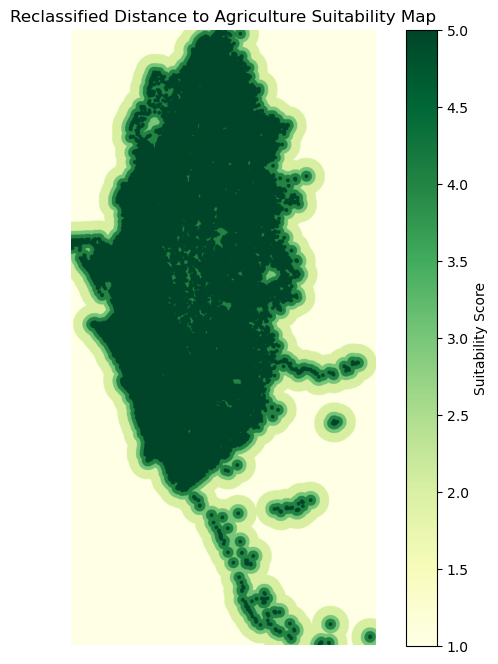

In [58]:
agriculture_distance_reclass_display = np.where(
    agriculture_distance_reclass == -9999,
    np.nan,
    agriculture_distance_reclass
)

fig, ax = plt.subplots(figsize=(8, 8))

agri_distance_map = ax.imshow(
    agriculture_distance_reclass_display,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Reclassified Distance to Agriculture Suitability Map")
ax.axis("off")

plt.colorbar(
    agri_distance_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

In [59]:
agriculture_distance_reclass_path = processed / "kitui_distance_to_agriculture_reclassified_100m.tif"

agriculture_distance_reclass_meta = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "dtype": "float32",
    "crs": reference_crs,
    "transform": transform,
    "nodata": -9999
}

with rasterio.open(agriculture_distance_reclass_path, "w", **agriculture_distance_reclass_meta) as dst:
    dst.write(agriculture_distance_reclass.astype("float32"), 1)

print("Done")

Done


## Preparing Criteria Layers for Weighted Overlay

Before weighted overlay analysis, all reclassified criteria rasters must have the same CRS, resolution, extent, transform, height, and width. Since the distance layers were created at 100 m resolution to reduce memory demand, the other reclassified rasters are resampled to the same 100 m analysis grid.

This ensures that slope, rainfall, land cover, soil depth, soil type, distance to roads, and distance to agriculture can be combined correctly in the AHP-based suitability model.

In [60]:
# Reclassified raster paths
slope_reclass_path = processed / "kitui_slope_reclassified.tif"
rainfall_reclass_path = processed / "kitui_rainfall_reclassified.tif"
landcover_reclass_path = processed / "kitui_landcover_reclassified.tif"
soil_depth_reclass_path = processed / "kitui_soil_depth_reclassified.tif"
soil_type_reclass_path = processed / "kitui_soil_type_reclassified.tif"
roads_distance_reclass_path = processed / "kitui_distance_to_roads_reclassified_100m.tif"
agriculture_distance_reclass_path = processed / "kitui_distance_to_agriculture_reclassified_100m.tif"

In [61]:
aligned_folder = processed / "aligned_100m"
aligned_folder.mkdir(exist_ok=True)

print("Done")

Done


In [62]:
reference_path = agriculture_distance_reclass_path

with rasterio.open(reference_path) as ref:
    reference_crs = ref.crs
    reference_transform = ref.transform
    reference_height = ref.height
    reference_width = ref.width
    reference_shape = ref.shape

print("Reference CRS:", reference_crs)
print("Reference shape:", reference_shape)
print("Reference resolution:", ref.res)

Reference CRS: EPSG:32737
Reference shape: (3333, 1646)
Reference resolution: (100.0, 100.0)


In [63]:
from rasterio.warp import reproject, Resampling

def align_raster_to_reference(input_path, output_path, resampling_method=Resampling.nearest):
    """
    Align a raster to the common 100 m reference grid.
    """
    with rasterio.open(input_path) as src:
        source_data = src.read(1)

        aligned_data = np.full(
            (reference_height, reference_width),
            -9999,
            dtype="float32"
        )

        reproject(
            source=source_data,
            destination=aligned_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=reference_transform,
            dst_crs=reference_crs,
            resampling=resampling_method,
            src_nodata=src.nodata,
            dst_nodata=-9999
        )

        meta = src.meta.copy()
        meta.update({
            "driver": "GTiff",
            "height": reference_height,
            "width": reference_width,
            "crs": reference_crs,
            "transform": reference_transform,
            "dtype": "float32",
            "nodata": -9999,
            "count": 1
        })

        with rasterio.open(output_path, "w", **meta) as dst:
            dst.write(aligned_data.astype("float32"), 1)

    print(f"Aligned raster saved: {output_path.name}")

In [64]:
align_raster_to_reference(
    slope_reclass_path,
    aligned_folder / "slope_reclass_100m.tif"
)

align_raster_to_reference(
    rainfall_reclass_path,
    aligned_folder / "rainfall_reclass_100m.tif"
)

align_raster_to_reference(
    landcover_reclass_path,
    aligned_folder / "landcover_reclass_100m.tif"
)

align_raster_to_reference(
    soil_depth_reclass_path,
    aligned_folder / "soil_depth_reclass_100m.tif"
)

align_raster_to_reference(
    soil_type_reclass_path,
    aligned_folder / "soil_type_reclass_100m.tif"
)

align_raster_to_reference(
    roads_distance_reclass_path,
    aligned_folder / "roads_distance_reclass_100m.tif"
)

align_raster_to_reference(
    agriculture_distance_reclass_path,
    aligned_folder / "agriculture_distance_reclass_100m.tif"
)

Aligned raster saved: slope_reclass_100m.tif
Aligned raster saved: rainfall_reclass_100m.tif
Aligned raster saved: landcover_reclass_100m.tif
Aligned raster saved: soil_depth_reclass_100m.tif
Aligned raster saved: soil_type_reclass_100m.tif
Aligned raster saved: roads_distance_reclass_100m.tif
Aligned raster saved: agriculture_distance_reclass_100m.tif


In [65]:
aligned_files = list(aligned_folder.glob("*.tif"))

for file in aligned_files:
    with rasterio.open(file) as src:
        print(file.name, src.crs, src.res, src.shape)

agriculture_distance_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
landcover_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
rainfall_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
roads_distance_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
slope_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
soil_depth_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)
soil_type_reclass_100m.tif EPSG:32737 (100.0, 100.0) (3333, 1646)


## AHP Weighted Overlay Analysis

The aligned reclassified criteria rasters are combined using an AHP-based weighted overlay approach. Each raster contains suitability scores from 1 to 5, where higher values represent higher suitability.

The weighted overlay combines slope, rainfall, land cover, soil depth, soil type, distance to roads, and distance to agricultural areas into a final composite suitability raster.

In [66]:
from pathlib import Path

# Define processed folder
processed = Path("../data/processed")

# Define folder where aligned 100 m rasters are stored
aligned_folder = processed / "aligned_100m"

# Create the folder if it does not already exist
aligned_folder.mkdir(exist_ok=True)

print("Aligned folder:", aligned_folder)

Aligned folder: ..\data\processed\aligned_100m


In [67]:
aligned_slope_path = aligned_folder / "slope_reclass_100m.tif"
aligned_rainfall_path = aligned_folder / "rainfall_reclass_100m.tif"
aligned_landcover_path = aligned_folder / "landcover_reclass_100m.tif"
aligned_soil_depth_path = aligned_folder / "soil_depth_reclass_100m.tif"
aligned_soil_type_path = aligned_folder / "soil_type_reclass_100m.tif"
aligned_roads_path = aligned_folder / "roads_distance_reclass_100m.tif"
aligned_agriculture_path = aligned_folder / "agriculture_distance_reclass_100m.tif"

## Weighted Overlay Calculation

All aligned criteria rasters are loaded and combined using AHP-based weights. Each raster contains suitability scores from 1 to 5, and the weighted overlay produces a final composite road water harvesting suitability score.

In [68]:
def read_raster_as_float(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        nodata = src.nodata
        meta = src.meta.copy()

    data = np.where(data == nodata, np.nan, data)

    return data, meta

In [69]:
slope_arr, reference_meta = read_raster_as_float(aligned_slope_path)
rainfall_arr, _ = read_raster_as_float(aligned_rainfall_path)
landcover_arr, _ = read_raster_as_float(aligned_landcover_path)
soil_depth_arr, _ = read_raster_as_float(aligned_soil_depth_path)
soil_type_arr, _ = read_raster_as_float(aligned_soil_type_path)
roads_arr, _ = read_raster_as_float(aligned_roads_path)
agriculture_arr, _ = read_raster_as_float(aligned_agriculture_path)

print("Done")

Done


In [70]:
weights = {
    "rainfall": 0.25,
    "slope": 0.20,
    "soil_type": 0.15,
    "soil_depth": 0.15,
    "landcover": 0.10,
    "distance_to_roads": 0.10,
    "distance_to_agriculture": 0.05
}

print("Total weight:", sum(weights.values()))

Total weight: 1.0


In [71]:
suitability = (
    rainfall_arr * weights["rainfall"] +
    slope_arr * weights["slope"] +
    soil_type_arr * weights["soil_type"] +
    soil_depth_arr * weights["soil_depth"] +
    landcover_arr * weights["landcover"] +
    roads_arr * weights["distance_to_roads"] +
    agriculture_arr * weights["distance_to_agriculture"]
)

print("Minimum suitability:", np.nanmin(suitability))
print("Maximum suitability:", np.nanmax(suitability))
print("Mean suitability:", np.nanmean(suitability))

Minimum suitability: 2.3999999
Maximum suitability: 4.85
Mean suitability: 3.7749088


## Visualizing Final Suitability Map

The final weighted overlay raster is visualized to show the spatial distribution of road water harvesting suitability across Kitui County. Higher values indicate areas with greater suitability based on the combined influence of rainfall, slope, soil type, soil depth, land cover, distance to roads, and distance to agriculture.

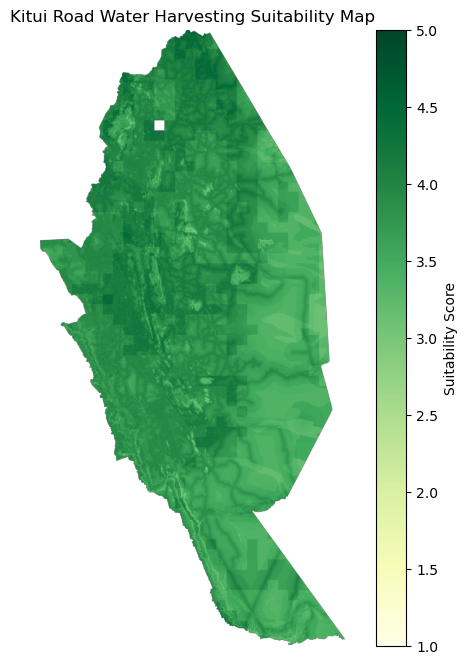

In [72]:
fig, ax = plt.subplots(figsize=(8, 8))

suitability_map = ax.imshow(
    suitability,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Kitui Road Water Harvesting Suitability Map")
ax.axis("off")

plt.colorbar(
    suitability_map,
    ax=ax,
    label="Suitability Score"
)

plt.show()

In [73]:
suitability_path = processed / "kitui_rwh_suitability_weighted_overlay_100m.tif"

# Replace NaN values with NoData for saving
suitability_output = np.where(
    np.isnan(suitability),
    -9999,
    suitability
)

# Update metadata
reference_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

# Save final suitability raster
with rasterio.open(suitability_path, "w", **reference_meta) as dst:
    dst.write(suitability_output.astype("float32"), 1)

print("Done")

Done


In [74]:
with rasterio.open(suitability_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("NoData:", src.nodata)

CRS: EPSG:32737
Resolution: (100.0, 100.0)
Shape: (3333, 1646)
NoData: -9999.0


## Final Suitability Classification

The weighted overlay produces continuous suitability scores. These scores are reclassified into five final suitability classes to make the results easier to interpret and map. The final classes represent areas ranging from not suitable to highly suitable for road water harvesting.

In [75]:
print("Minimum suitability:", np.nanmin(suitability))
print("Maximum suitability:", np.nanmax(suitability))
print("Mean suitability:", np.nanmean(suitability))

Minimum suitability: 2.3999999
Maximum suitability: 4.85
Mean suitability: 3.7749088


In [76]:
min_score = np.nanmin(suitability)
max_score = np.nanmax(suitability)

class_breaks = np.linspace(min_score, max_score, 6)

print("Class breaks:", class_breaks)

Class breaks: [2.3999999 2.8899999 3.3799999 3.87      4.3599997 4.85     ]


In [77]:
final_suitability_class = np.full(suitability.shape, -9999, dtype="float32")

final_suitability_class[
    (suitability >= class_breaks[0]) & (suitability <= class_breaks[1])
] = 1

final_suitability_class[
    (suitability > class_breaks[1]) & (suitability <= class_breaks[2])
] = 2

final_suitability_class[
    (suitability > class_breaks[2]) & (suitability <= class_breaks[3])
] = 3

final_suitability_class[
    (suitability > class_breaks[3]) & (suitability <= class_breaks[4])
] = 4

final_suitability_class[
    (suitability > class_breaks[4]) & (suitability <= class_breaks[5])
] = 5

print("Done")

Done


In [78]:
unique_classes, counts = np.unique(
    final_suitability_class[final_suitability_class != -9999],
    return_counts=True
)

print("Final suitability classes:", unique_classes)
print("Pixel counts:", counts)

Final suitability classes: [1. 2. 3. 4. 5.]
Pixel counts: [   1851  328111 1480924 1195845   30254]


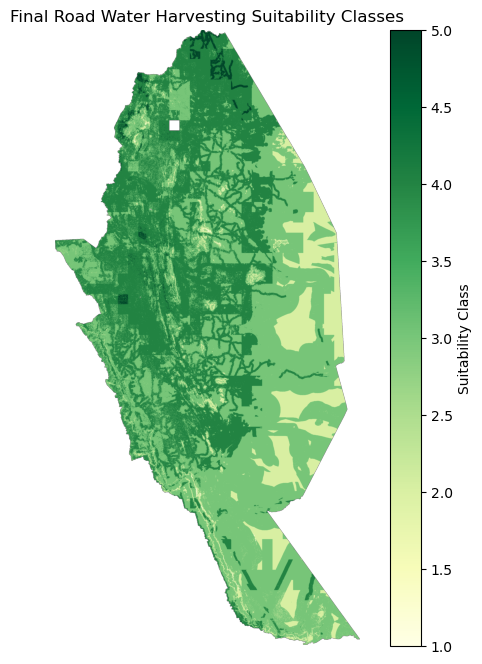

In [79]:
final_suitability_display = np.where(
    final_suitability_class == -9999,
    np.nan,
    final_suitability_class
)

fig, ax = plt.subplots(figsize=(8, 8))

final_map = ax.imshow(
    final_suitability_display,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Final Road Water Harvesting Suitability Classes")
ax.axis("off")

plt.colorbar(
    final_map,
    ax=ax,
    label="Suitability Class"
)

plt.show()

## Saving Final Classified Suitability Raster

The final classified suitability raster is saved as a GeoTIFF file. This raster contains five suitability classes representing the final road water harvesting suitability zones for Kitui County.

In [80]:
# Define output path for final classified suitability raster
final_suitability_class_path = processed / "kitui_rwh_final_suitability_classes_100m.tif"

# Replace NoData/NaN values with -9999 for saving
final_class_output = np.where(
    final_suitability_class == -9999,
    -9999,
    final_suitability_class
)

# Update metadata using the reference raster metadata
reference_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": -9999,
    "count": 1
})

# Save final classified suitability raster
with rasterio.open(final_suitability_class_path, "w", **reference_meta) as dst:
    dst.write(final_class_output.astype("float32"), 1)

print("Done")

Done


In [81]:
with rasterio.open(final_suitability_class_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("NoData:", src.nodata)

    final_check = src.read(1)

unique_classes, counts = np.unique(
    final_check[final_check != -9999],
    return_counts=True
)

print("Final suitability classes:", unique_classes)
print("Pixel counts:", counts)

CRS: EPSG:32737
Resolution: (100.0, 100.0)
Shape: (3333, 1646)
NoData: -9999.0
Final suitability classes: [1. 2. 3. 4. 5.]
Pixel counts: [   1851  328111 1480924 1195845   30254]


## Exporting Final Suitability Map

The final classified suitability raster is exported as a map image for presentation and GitHub documentation. This output will be used in the README file to visually communicate the results of the road water harvesting suitability analysis.

In [82]:
from pathlib import Path

maps_folder = Path("../outputs/maps")
maps_folder.mkdir(parents=True, exist_ok=True)

final_map_png = maps_folder / "kitui_rwh_final_suitability_map.png"

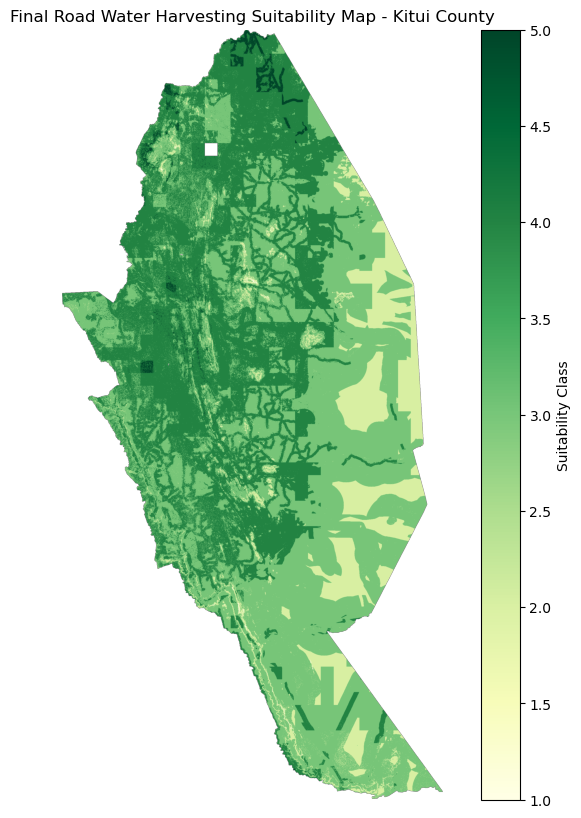

Final map exported successfully: ..\outputs\maps\kitui_rwh_final_suitability_map.png


In [83]:

# Prepare raster for display
final_suitability_display = np.where(
    final_suitability_class == -9999,
    np.nan,
    final_suitability_class
)

# Plot and export map
fig, ax = plt.subplots(figsize=(10, 10))

final_map = ax.imshow(
    final_suitability_display,
    cmap="YlGn",
    vmin=1,
    vmax=5
)

ax.set_title("Final Road Water Harvesting Suitability Map - Kitui County")
ax.axis("off")

plt.colorbar(
    final_map,
    ax=ax,
    label="Suitability Class"
)

plt.savefig(final_map_png, dpi=300, bbox_inches="tight")
plt.show()

print("Final map exported successfully:", final_map_png)